# Linear Motion Deblurring

This notebook is developed based on: 
> Hansen, P. C., Nagy, J. G., & O'Leary, D. P. (2006). Deblurring images: Matrices, spectra, and filtering. SIAM, Society for Industrial and Applied Mathematics. https://doi.org/10.1137/1.9780898718874

In [1]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

----------
### Convert An Image File Into Normalized NumPy Array using Pillow
> Pillow Documentation (https://pillow.readthedocs.io/en/stable/index.html)

In [2]:
##############################################################################
# Note: .convert('L') is to make sure the image mode is in grayscale 
#       as common photo editors tend to use RGB even for black & white images.
##############################################################################

def convert_img_to_norm_np_arr(input_location, output_name, grayscale=False, save_converted_img=True):
    """Convert given image to normalized pixel values from [0,255] to [0,1] in Numpy array."""
    
    output_location = './motion_deblur_img/output/'
    os.makedirs(output_location, exist_ok=True)
    img = Image.open(input_location).convert('L') if grayscale else Image.open(input_location)
    
    if save_converted_img:
        img.save(os. path.join(output_location, output_name))
        
    return np.array(img).astype(np.float64) / 255

----------
### Build Point Spread Function (PSF) for horizontal/vertical motion blur
> Hansen et al.(2006), Chapter 3.3 - Obtaining the PSF (p.25)

In [3]:
def build_horizontal_motion_psf(length, img_shape):
    """Build horizontal motion psf with padding zeros."""
    
    psf = np.zeros(img_shape)
    psf[0, :length] = 1 / length
    return psf

def build_vertical_motion_psf(length, img_shape):
    """Build vertical motion psf with padding zeros."""
    
    psf = np.zeros(img_shape)
    psf[:length, 0] = 1 / length
    return psf

----------
### Compute a blurred image from the original image
> Hansen et al.(2006), Chapter 4.2.2 - Computations with BCCB Matrices (p.44)

In [4]:
def compute_blurred_img(psf, orig_img, noise_amount=0.01):
    """Return the blurred image array by given psf."""
    
    eigen_of_A = np.fft.fft2(psf)
    blurred = np.real(np.fft.ifft2(eigen_of_A * np.fft.fft2(orig_img)))
    noise = noise_amount * np.random.randn(*orig_img.shape)
    
    return blurred + noise

----------
### Compute a naive solution from the blurred image
> Hansen et al.(2006), Chapter 4.2.2 - Computations with BCCB Matrices (p.44)

In [5]:
def compute_naive_solution(psf, blurred_img):
    eigen_of_A = np.fft.fft2(psf)
    return np.real(np.fft.ifft2(np.fft.fft2(blurred_img) / eigen_of_A))

----------
### Compute Truncated SVD (Singular Value Decomposition)
> **Hansen et al.(2006)**
> - Chapter 5.1 - Introduction to Spectral Filtering (p.55-56)
> - Chapter 6.2 - Implementation of Filtering Methods (p.74-75)

In [6]:
def compute_tsvd(psf, blurred_img, tol):
    eigen_of_A = np.fft.fft2(psf)
    tsvd_filter = np.abs(eigen_of_A) >= tol
    filtered = np.where(tsvd_filter, (1 / eigen_of_A), 0)
    
    return np.real(np.fft.ifft2(np.fft.fft2(blurred_img) * filtered))

----------
### Compute Tikhonov Regularization
> **Hansen et al.(2006)**
> - Chapter 6.1 - Two Important Methods (p.72-73)
> - Chapter 6.2 - Implementation of Filtering Methods (p.74-75)

In [7]:
def compute_tikhonov(psf, blurred_img, alpha):
    eigen_of_A = np.fft.fft2(psf)
    tikhonov_filter = (np.abs(eigen_of_A) ** 2) / ( (np.abs(eigen_of_A) ** 2) + (alpha ** 2) )
    filtered =  tikhonov_filter / eigen_of_A
    
    return np.real(np.fft.ifft2(np.fft.fft2(blurred_img) * filtered))

def get_alpha_min_max(psf):
    eigen_of_A = np.fft.fft2(psf)
    alpha_min = np.min(np.abs(eigen_of_A))
    alpha_max = np.max(np.abs(eigen_of_A))
    
    return (alpha_min, alpha_max)

----------
### Build PSF for Linear Motion Blur at Various Angles

In [8]:
def get_pixel_pos_for_angled_linear_motion(length, angle_deg):
    """Return a list of pixel coordinates for a motion blur line of given length and angle.
    All the position is shifted to positive axis to align it for psf."""
    
    len_list = np.linspace(0, length - 1, num=(length * 2))
    pos_set = set()
    shifted_rad = np.radians(angle_deg) + (np.pi / 2)

    for l in len_list:
        x_pos = abs(round( np.cos(shifted_rad) * l ))
        y_pos = abs(round( np.sin(shifted_rad) * l ))
        pos_set.add((x_pos, y_pos))
        
    return list(pos_set)
    
def build_linear_motion_psf(length, angle_deg, img_shape):
    """Build angled linear motion psf with padding zeros."""
    
    psf = np.zeros(img_shape)
    positions = get_pixel_pos_for_angled_linear_motion(length, angle_deg)
    pos_count = len(positions)
    for pos in positions:
        psf[*pos] = 1 / pos_count
        
    return psf

def transform_img(angle_deg, orig_img):
    """Transform the image so the motion blur aligns with the given angle for psf computation."""
    
    deg = (angle_deg % 360)
    if 0 <= deg <= 90:
        return np.flipud(orig_img)
    elif 90 < deg <= 180:
        return np.fliplr(np.flipud(orig_img))
    elif 180 < deg <= 270:
        return np.fliplr(orig_img)
    
    return orig_img

def compute_linear_motion_blur(length, angle_deg, orig_img, noise_amount=0.01):
    """Return the linear motion blurred frequency domain array by the given length and angle."""
    
    trans_img = transform_img(angle_deg, orig_img)
    psf = build_linear_motion_psf(length, angle_deg, trans_img.shape)
    
    eigen_of_A = np.fft.fft2(psf)
    blurred = np.real(np.fft.ifft2(eigen_of_A * np.fft.fft2(trans_img)))
    noise = noise_amount * np.random.randn(*trans_img.shape)
    
    result_img = transform_img(angle_deg, (blurred + noise))
    return result_img

def plot_l_curve_linear_motion(deblur_func, length, angle_deg, blurred_img, min_val, max_val, title, at_val):
    trans_img = transform_img(angle_deg, blurred_img)
    psf = build_linear_motion_psf(length, angle_deg, trans_img.shape)
    plot_l_curve(deblur_func, psf, trans_img, min_val, max_val, title, at_val)
    
def compute_linear_motion_deblur(deblur_func, length, angle_deg, blurred_img, alpha):
    """Return deblurred frequency domain array by the given length and angle."""
    
    trans_img = transform_img(angle_deg, blurred_img)
    psf = build_linear_motion_psf(length, angle_deg, trans_img.shape)
    
    deblurred = deblur_func(psf, trans_img, alpha)
    result_img = transform_img(angle_deg, deblurred)
    
    return result_img
    

----------
### Visualization

In [9]:
# plot L-curve (log-log plot) to find optimal value

def get_solution_residual_norms(deblur_func, psf, blurred_img, at_val):
    eigen_of_A = np.fft.fft2(psf)
    soln = deblur_func(psf, blurred_img, at_val)
    solution_norm = np.linalg.norm(soln)
    residual_norm = np.linalg.norm(blurred_img - np.real(np.fft.ifft2(eigen_of_A * np.fft.fft2(soln))))
    
    return solution_norm, residual_norm

def plot_l_curve(deblur_func, psf, blurred_img, min_val, max_val, title, at_val):
    _, plot = plt.subplots(figsize=(5,4))
    linvals = np.linspace(min_val, max_val, num=100)
    solution_norms = []
    residual_norms = []
    
    for val in linvals:
        solution_norm, residual_norm = get_solution_residual_norms(deblur_func, psf, blurred_img, val)
        solution_norms.append(solution_norm)
        residual_norms.append(residual_norm)

    plot.loglog(residual_norms, solution_norms, '-o', markersize=3)

    # plot point for the given specific at_val
    solution_norm, residual_norm = get_solution_residual_norms(deblur_func, psf, blurred_img, at_val)
    plot.plot(residual_norm, solution_norm, 'o')
    plot.annotate(f'{at_val:.3f}', (residual_norm, solution_norm), xytext=(5,0), textcoords='offset points')
        
    plt.xlabel("Residual Norm ||b-Ax||")
    plt.ylabel("solution Norm ||x||")
    plt.title(title)
    plt.show()

In [10]:
def plot_comparison(arr_list, label_list, row, col, figsize=(12,4), cmap=None):
    """Plot images side by side for comparison."""
    
    _, sub = plt.subplots(row, col, figsize=figsize)
    sub = sub.flatten()
    [s.axis('off') for s in sub]
    
    for sub_idx in range(len(arr_list)):
        sub[sub_idx].imshow(arr_list[sub_idx], cmap=cmap)
        sub[sub_idx].set_title(label_list[sub_idx], y=-0.1)
        
    plt.subplots_adjust(wspace=0.1, hspace=0)
    plt.show()

----------
----------
## Example 1
> Image Credit: [Arturo Anez from Pixabay](https://pixabay.com/photos/cat-pet-animal-nature-domestic-cat-9569386/)
### Horizontal/Vertical Motion Blur with a Grayscale Image

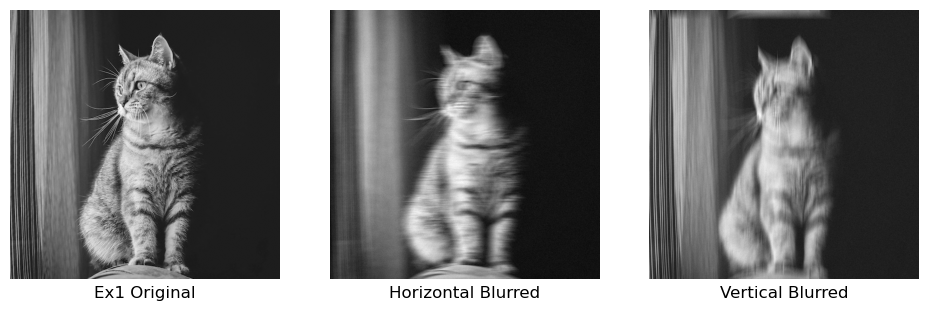

In [11]:
ex1_gray_arr = convert_img_to_norm_np_arr('./motion_deblur_img/input/Image_by_Arturo_Anez_from_Pixabay.jpg',
                                          'ex1_grayscale.jpg',
                                          grayscale=True)
length = 20
ex1_h_psf = build_horizontal_motion_psf(length, ex1_gray_arr.shape)
ex1_h_blurred = compute_blurred_img(ex1_h_psf, ex1_gray_arr)
ex1_v_psf = build_vertical_motion_psf(length, ex1_gray_arr.shape)
ex1_v_blurred = compute_blurred_img(ex1_v_psf, ex1_gray_arr)

plot_comparison([ex1_gray_arr, ex1_h_blurred, ex1_v_blurred],
          ['Ex1 Original', 'Horizontal Blurred', 'Vertical Blurred'],
          1, 3, figsize=(12, 3.5), cmap='gray')

### Deblur Method Comparison with Horizontal Blurred Image
### [Naive Solutions]

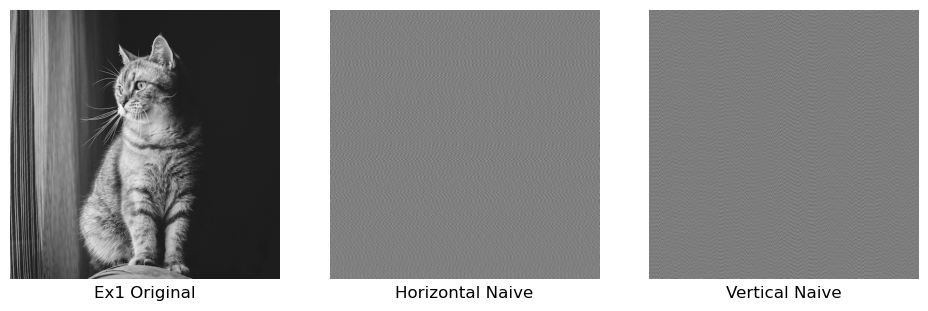

In [12]:
ex1_h_naive = compute_naive_solution(ex1_h_psf, ex1_h_blurred)
ex1_v_naive = compute_naive_solution(ex1_v_psf, ex1_v_blurred)

plot_comparison([ex1_gray_arr, ex1_h_naive, ex1_v_naive],
          ['Ex1 Original', 'Horizontal Naive', 'Vertical Naive'],
          1, 3, figsize=(12, 3.5), cmap='gray')

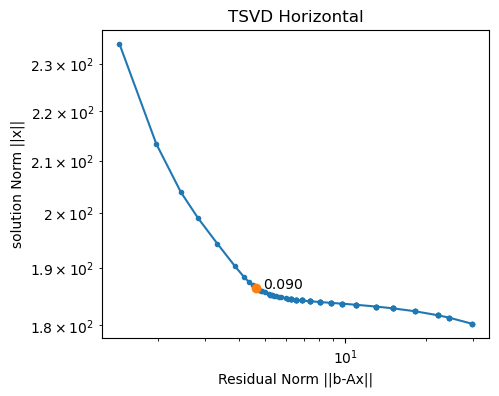

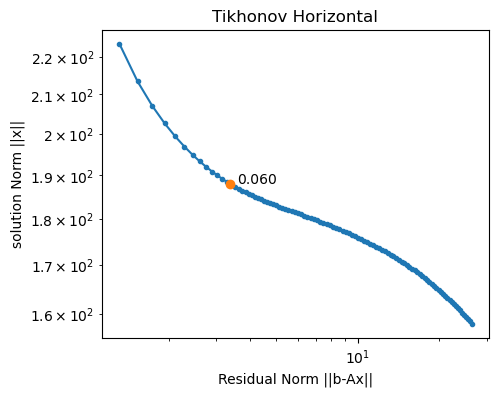

In [13]:
min_max = get_alpha_min_max(ex1_h_psf)
ex1_h_tsvd_tol = 0.090
ex1_h_tikhonov_alpha = 0.060

plot_l_curve(compute_tsvd, ex1_h_psf, ex1_h_blurred, 
             min_max[0]+0.01, min_max[1]-0.1, 'TSVD Horizontal', ex1_h_tsvd_tol)
plot_l_curve(compute_tikhonov, ex1_h_psf, ex1_h_blurred, 
             min_max[0]+0.01, min_max[1]-0.6, 'Tikhonov Horizontal', ex1_h_tikhonov_alpha)

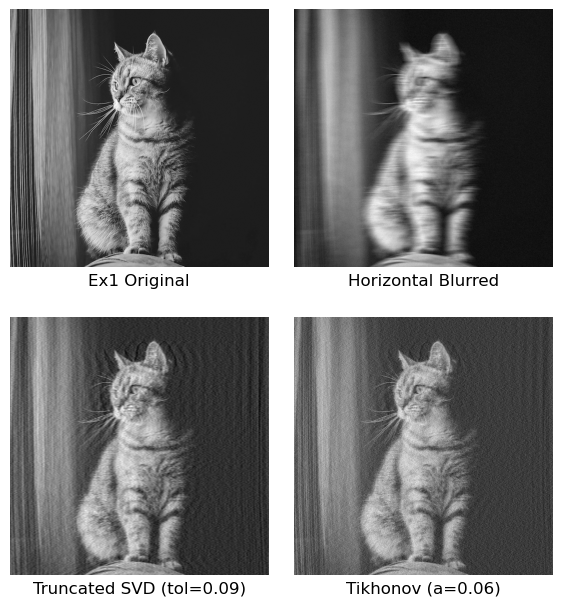

In [14]:
ex1_h_tsvd = compute_tsvd(ex1_h_psf, ex1_h_blurred, ex1_h_tsvd_tol)
ex1_h_tikhonov = compute_tikhonov(ex1_h_psf, ex1_h_blurred, ex1_h_tikhonov_alpha)

plot_comparison([ex1_gray_arr, ex1_h_blurred, ex1_h_tsvd, ex1_h_tikhonov],
          ['Ex1 Original', 'Horizontal Blurred', f'Truncated SVD (tol={ex1_h_tsvd_tol})', f'Tikhonov (a={ex1_h_tikhonov_alpha})'],
          2, 2, figsize=(7, 8), cmap='gray')

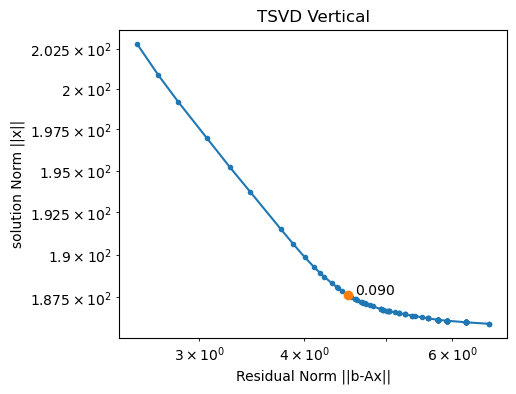

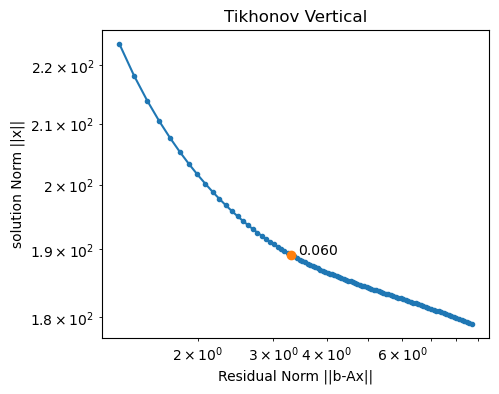

In [15]:
min_max = get_alpha_min_max(ex1_v_psf)
ex1_v_tsvd_tol = 0.090
ex1_v_tikhonov_alpha = 0.060

plot_l_curve(compute_tsvd, ex1_v_psf, ex1_v_blurred, 
             min_max[0]+0.03, min_max[1]-0.6, 'TSVD Vertical', ex1_v_tsvd_tol)
plot_l_curve(compute_tikhonov, ex1_v_psf, ex1_v_blurred, 
             min_max[0]+0.01, min_max[1]-0.8, 'Tikhonov Vertical', ex1_v_tikhonov_alpha)

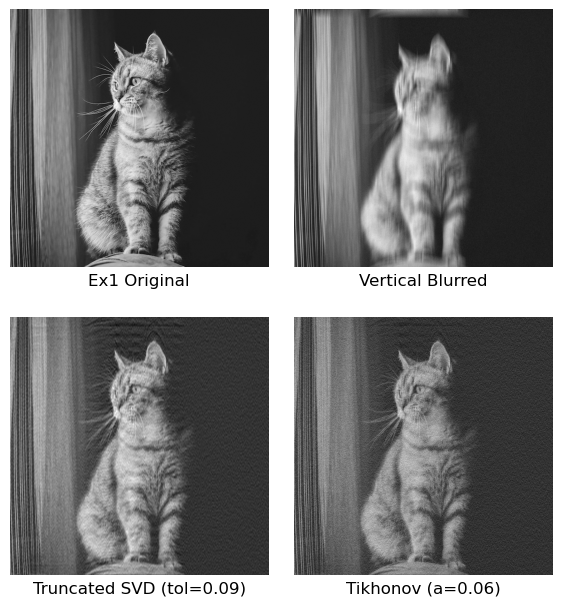

In [16]:
ex1_v_naive = compute_naive_solution(ex1_v_psf, ex1_v_blurred)
ex1_v_tsvd = compute_tsvd(ex1_v_psf, ex1_v_blurred, ex1_v_tsvd_tol)
ex1_v_tikhonov = compute_tikhonov(ex1_v_psf, ex1_v_blurred, ex1_v_tikhonov_alpha)

plot_comparison([ex1_gray_arr, ex1_v_blurred, ex1_v_tsvd, ex1_v_tikhonov],
          ['Ex1 Original', 'Vertical Blurred', f'Truncated SVD (tol={ex1_v_tsvd_tol})', f'Tikhonov (a={ex1_v_tikhonov_alpha})'],
          2, 2, figsize=(7, 8), cmap='gray')

----------
----------
## Example 2
> Image Credit: [Pavel_from_Pixabay](https://pixabay.com/photos/cat-kitten-tree-curious-tabby-1647775/)

### Linear Motion Blur at Various Angles with a Grayscale Image

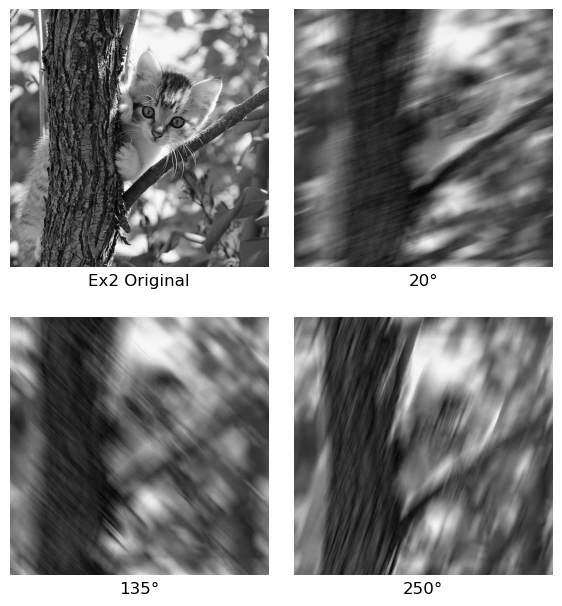

In [17]:
ex2_gray_arr = convert_img_to_norm_np_arr('./motion_deblur_img/input/Image_by_Pavel_from_Pixabay.jpg',
                                          'ex2_grayscale.jpg',
                                          grayscale=True)
length = 50
ex2_20_blurred = compute_linear_motion_blur(length, 20, ex2_gray_arr)
ex2_135_blurred = compute_linear_motion_blur(length, 135, ex2_gray_arr)
ex2_250_blurred = compute_linear_motion_blur(length, 250, ex2_gray_arr)

plot_comparison([ex2_gray_arr, ex2_20_blurred, ex2_135_blurred, ex2_250_blurred],
          ['Ex2 Original', '20°', '135°', '250°'],
          2, 2, figsize=(7, 8), cmap='gray')

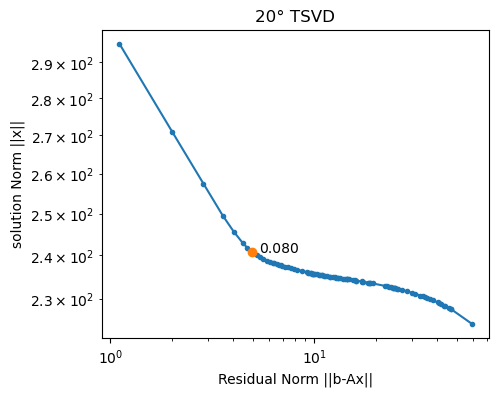

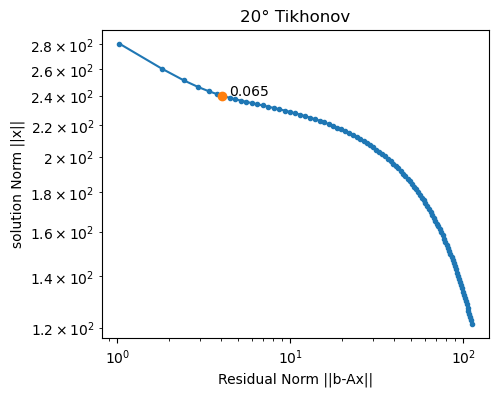

In [18]:
ex2_20_tsvd_tol = 0.08
ex2_20_tikhonov_alpha = 0.065
plot_l_curve_linear_motion(compute_tsvd, length, 20, ex2_20_blurred, 0.01, 0.95, '20° TSVD', ex2_20_tsvd_tol)
plot_l_curve_linear_motion(compute_tikhonov, length, 20, ex2_20_blurred, 0.01, 0.95, '20° Tikhonov', ex2_20_tikhonov_alpha)

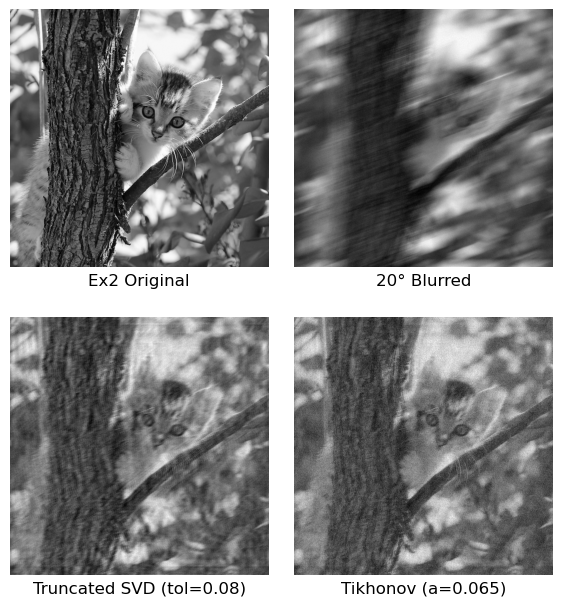

In [19]:
ex2_20_tsvd = compute_linear_motion_deblur(compute_tsvd, length, 20, ex2_20_blurred, 0.08)
ex2_20_tikhonov = compute_linear_motion_deblur(compute_tikhonov, length, 20, ex2_20_blurred, 0.065)

plot_comparison([ex2_gray_arr, ex2_20_blurred, ex2_20_tsvd, ex2_20_tikhonov],
          ['Ex2 Original', '20° Blurred', f'Truncated SVD (tol={ex2_20_tsvd_tol})', f'Tikhonov (a={ex2_20_tikhonov_alpha})'],
          2, 2, figsize=(7, 8), cmap='gray')